# LSTM Pipeline for Coffee Humidity Prediction 

This notebook implements a full pipeline to train and evaluate LSTM models that predict coffee humidity (target: `Humidity_Coffee`) using sensor and environmental data. The workflow combines original DH200X sheets and additional experiment sheets, prepares the data, trains LSTM models with different activation settings, and compares predictions and metrics across regions.

---

## Required files / inputs

- `New data.xlsx` — expected to contain sheets:
  - `Genova DH200X`, `Alban DH200X`, `Sandona DH200X` (or equivalent names)
- `Drying_Data.xlsx` — expected to contain experimental sheets:
  - `Experimento 1 GENOVA`, `Experimento 2 Albán`, `Experimento 3 Sandoná`
- The code expects these sheets to include (at least):
  - `Temperature_Overall`
  - `Humidity_Overall`
  - `Temperature_Coffee`
  - `Humidity_Coffee` (target)
  - Optionally `Section` (values like `M1 Superior`, `M2 Medio`, `M3 Inferior`)

## Outputs 
- Plots produced inline in the notebook:
  - Training vs validation loss per activation
  - Per-region prediction plots (actual vs predicted)
  - Combined activation comparison plots
  - Metrics bar charts
- `results` dictionary that stores models, histories, metrics and predictions for later inspection or saving.
- Printed comparison table summarizing performance.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, LeakyReLU
from tensorflow.keras.optimizers import Nadam
import tensorflow as tf



###  Settings
Defines file paths, sheet names, region labels, and simple parameters.  
Key variables to adjust:
- `DATA_FILE_1`, `DATA_FILE_2`
- `sheet_names`, `region_labels`, `exp_sheets`, `exp_regions`
- `n_steps` (sequence length) and any other hyperparameters in the training loop.

In [8]:

#  Settings

DATA_FILE_1 = 'New data.xlsx'       # contains "Genova DH200X", "Alban DH200X", "Sandona DH200X"
DATA_FILE_2 = 'Drying_Data.xlsx'    # contains Experimento sheets
sheet_names = ['Genova DH200X', 'Alban DH200X', 'Sandona DH200X']
region_labels = ['Genova DX', 'Alban DX', 'Sandona DX']
exp_sheets = ['Experimento 1 GENOVA', 'Experimento 2 Albán', 'Experimento 3 Sandoná']
exp_regions = ['Genova DX', 'Alban DX', 'Sandona DX']

### 1. Load original DH200X data
Loads the main DH200X sheets from `DATA_FILE_1`, adds a `region` column, and normalizes `Section` strings (removes prefixes like `M1 `, `M2 `, `M3 `).


In [9]:
# 1- LOAD ORIGINAL DH200X DATA
dfs = []
for sheet, region in zip(sheet_names, region_labels):
    df = pd.read_excel(DATA_FILE_1, sheet_name=sheet)
    df['region'] = region
    if 'Section' in df.columns:
        df['Section'] = (
            df['Section']
            .astype(str)
            .str.replace('M1 ', '')
            .str.replace('M2 ', '')
            .str.replace('M3 ', '')
            .str.strip()
        )
    dfs.append(df)

### 2. Load additional experiment data
Loads experiment sheets from `DATA_FILE_2` and appends them to the same list of dataframes so all experiments and DH200X data are combined.


In [19]:

# 2. LOAD ADDITIONAL EXPERIMENT DATA
for sheet, region in zip(exp_sheets, exp_regions):
    df = pd.read_excel(DATA_FILE_2, sheet_name=sheet)
    df['region'] = region
    dfs.append(df)


data = pd.concat(dfs, ignore_index=True)

### 3. Clean and prepare merged data
- Strips whitespace and fixes common column typos (`Humedity_Coffee` → `Humidity_Coffee`).
- Ensures numeric columns exist and converts them to numeric safely (`errors='coerce').
- Drops rows with missing values in the required columns and resets the index.

In [21]:

# 3. CLEAN AND PREPARE THE MERGED DATA

data.columns = data.columns.str.strip().str.replace('Humedity_Coffee', 'Humidity_Coffee')

cols = ['Temperature_Overall', 'Humidity_Overall', 'Temperature_Coffee', 'Humidity_Coffee']
for col in cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    else:
        raise KeyError(f"Expected column '{col}' not found in data. Check file/sheet names and column headers.")

data.dropna(subset=cols, inplace=True)
data.reset_index(drop=True, inplace=True)

### 4. Encode categorical variables
- `LabelEncoder` is used to convert `region` (and `Section` if present) to integer labels so they can be included as features.


In [22]:

# 4. ENCODE CATEGORICAL VARIABLES

le_region = LabelEncoder()
data['region_encoded'] = le_region.fit_transform(data['region'].astype(str))

if 'Section' in data.columns:
    le_section = LabelEncoder()
    data['section_encoded'] = le_section.fit_transform(data['Section'].astype(str))

### 5. Define features and target
- `features = ['Temperature_Overall', 'Humidity_Overall', 'Temperature_Coffee', 'region_encoded']`
- `target = 'Humidity_Coffee'`
- If `Section` exists, data is split into training (`Superior`, `Medio`) and test/prediction (`Inferior`); otherwise, the whole dataset is used as training.

In [23]:

# 5. DEFINE FEATURES AND TARGET

features = ['Temperature_Overall', 'Humidity_Overall', 'Temperature_Coffee', 'region_encoded']
target = 'Humidity_Coffee'

# We split into training (Superior, Medio) and test (Inferior)
if 'Section' in data.columns:
    train_data = data[data['Section'].isin(['Superior', 'Medio'])].copy()
    m3_data = data[data['Section'] == 'Inferior'].copy()
else:
    train_data = data.copy()
    m3_data = pd.DataFrame(columns=data.columns)

### 6. Normalization
- Uses `MinMaxScaler` to rescale features and target to [0, 1] for stable LSTM training.
- Handles dtype conversions to `float` before scaling to avoid warnings.

In [29]:
# ======================================
# 6. NORMALIZATION
# ======================================

# Define features and target 
features = ['Temperature_Overall', 'Humidity_Overall', 'Temperature_Coffee', 'region_encoded']
target = target = 'Humidity_Coffee'

# Initialize scaler
scaler = MinMaxScaler()

# Get the columns we need to normalize
needed_cols = features + [target]

# Check if all columns exist
missing_cols = [col for col in needed_cols if col not in data.columns]
if missing_cols:
    print(f" Missing columns: {missing_cols}")
    print(f"Available columns: {data.columns.tolist()}")
else:
    # Convert to float and normalize
    data[needed_cols] = data[needed_cols].astype(float)
    data.loc[:, needed_cols] = scaler.fit_transform(data[needed_cols])
    
    print("✓ Normalization complete!")
    print(f"Normalized columns: {needed_cols}")
    print(f"\nSample of normalized data:")
    print(data[needed_cols].head())



✓ Normalization complete!
Normalized columns: ['Temperature_Overall', 'Humidity_Overall', 'Temperature_Coffee', 'region_encoded', 'Humidity_Coffee']

Sample of normalized data:
   Temperature_Overall  Humidity_Overall  Temperature_Coffee  region_encoded  \
0               0.3000          0.787234            0.286344             0.5   
1               0.3000          0.787234            0.308370             0.5   
2               0.3000          0.787234            0.370044             0.5   
3               0.3625          0.687109            0.400881             0.5   
4               0.3625          0.687109            0.418502             0.5   

   Humidity_Coffee  
0         0.615183  
1         0.591623  
2         0.568063  
3         0.575916  
4         0.562827  



### 7. Sequence creation
- `create_sequences(df, n_steps)` converts the tabular data into supervised sequences:
  - Each sample is an array of `n_steps` consecutive rows of features.
  - The label is the target value immediately after the sequence window.
- Raises an error if there are not enough rows to create at least one sequence.

In [30]:
# ======================================
# 7. SEQUENCE CREATION
# ======================================
def create_sequences(df, n_steps=15):
    X, y = [], []
    # sort by index/time if needed - assume order in dataframe is temporal
    for i in range(len(df) - n_steps):
        X.append(df[features].iloc[i:i+n_steps].values)
        y.append(df[target].iloc[i+n_steps])
    if len(X) == 0:
        return np.empty((0, n_steps, len(features))), np.empty((0,))
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, n_steps=15)
if X_train.size == 0:
    raise ValueError("No training sequences created. Check that train_data has at least (n_steps + 1) rows.")
    





### 8. Build model function
- `build_model(activation_fn)` constructs a Keras `Sequential` model:
  - Stacked LSTM layers: 128 → 96 → 64 units with Dropout between layers.
  - Dense block of 32 units optionally using the provided activation (or applying `LeakyReLU` layer when necessary).
  - Final Dense(1) for regression output.
  - Compiled with Nadam optimizer and MSE loss; MAE is tracked as a metric.


In [31]:
# ======================================
# 8. BUILD MODEL FUNCTION 
# ======================================
def build_model(activation_fn):
    """
    activation_fn: either a string (e.g. 'relu') or a Keras layer instance like LeakyReLU(...)
    For LSTM we use default activations (tanh) except when a string is provided for Dense layers.
    """
    use_leaky = isinstance(activation_fn, LeakyReLU)
    dense_activation = activation_fn if isinstance(activation_fn, str) else None

    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
    # Use default LSTM activation (tanh) usually; if user provided string we pass it to Dense layers
    model.add(LSTM(128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(96, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(64))
    model.add(Dropout(0.3))

    # Dense block
    if dense_activation is not None:
        model.add(Dense(32, activation=dense_activation))
    else:
        
        model.add(Dense(32))
        if use_leaky:
            model.add(activation_fn)

    model.add(Dense(1))  # final linear output

    model.compile(optimizer=Nadam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

### 9. Activation functions
- Defines a dictionary of activations to test:
  - `'ReLU', 'Tanh', 'Sigmoid', 'SELU', 'ELU', 'LeakyReLU'`
- Each activation will be used to build and train a separate model so you can compare their effect.


In [32]:
# ======================================
# 9. DEFINE ACTIVATION FUNCTIONS
# ======================================
activations = {
    'ReLU': 'relu',
    'Tanh': 'tanh',
    'Sigmoid': 'sigmoid',
    'SELU': 'selu',
    'ELU': 'elu',
    'LeakyReLU': LeakyReLU(negative_slope=0.01)
}

results = {}
regions = ['Genova DX', 'Alban DX', 'Sandona DX']

available_regions = [r for r in regions if r in train_data['region'].unique()]
if len(available_regions) == 0:
    raise ValueError("No regions from the list found in train_data['region']. Check names/capitalization.")
regions = available_regions

### 10. Training loop and per-region rolling predictions
For each activation:
- Train the model on all training sequences (`X_train`, `y_train`) with a validation split.
- For each region:
  - Use the first `n_steps` points as the initial (fitted) sequence.
  - Perform rolling predictions: at each step, predict the next humidity and shift the input window forward using the actual next features.
  - Inverse-transform scaled predictions back to original units for evaluation.
  - Compute evaluation metrics: MAE, RMSE, R².
  - Plot actual vs fitted vs predicted and show per-region metrics.


--- Training with ReLU activation function ---


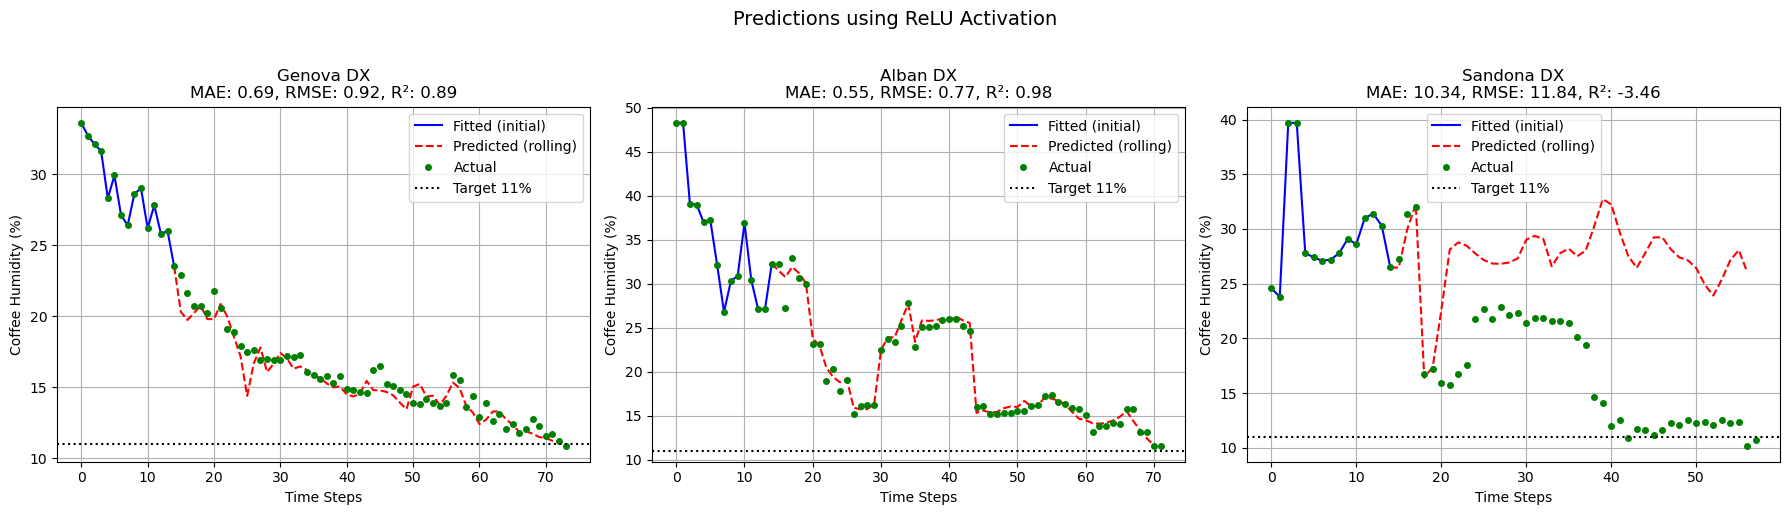


--- Training with Tanh activation function ---


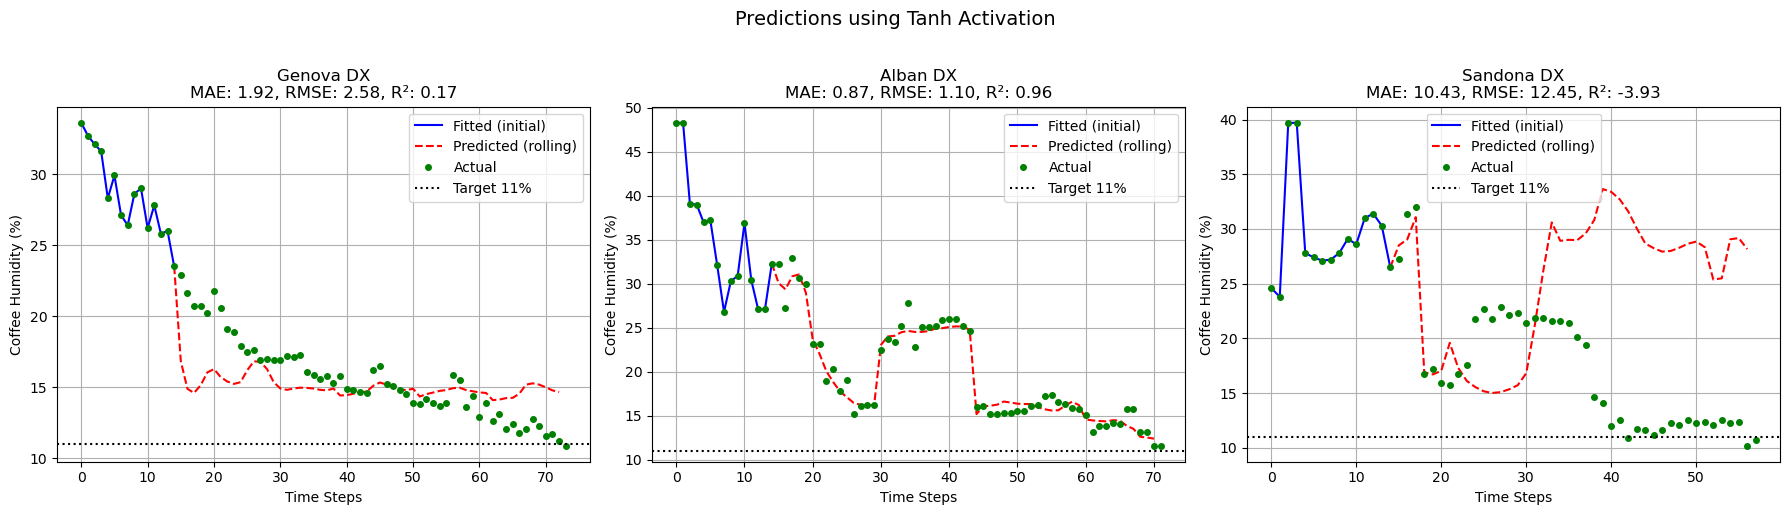


--- Training with Sigmoid activation function ---


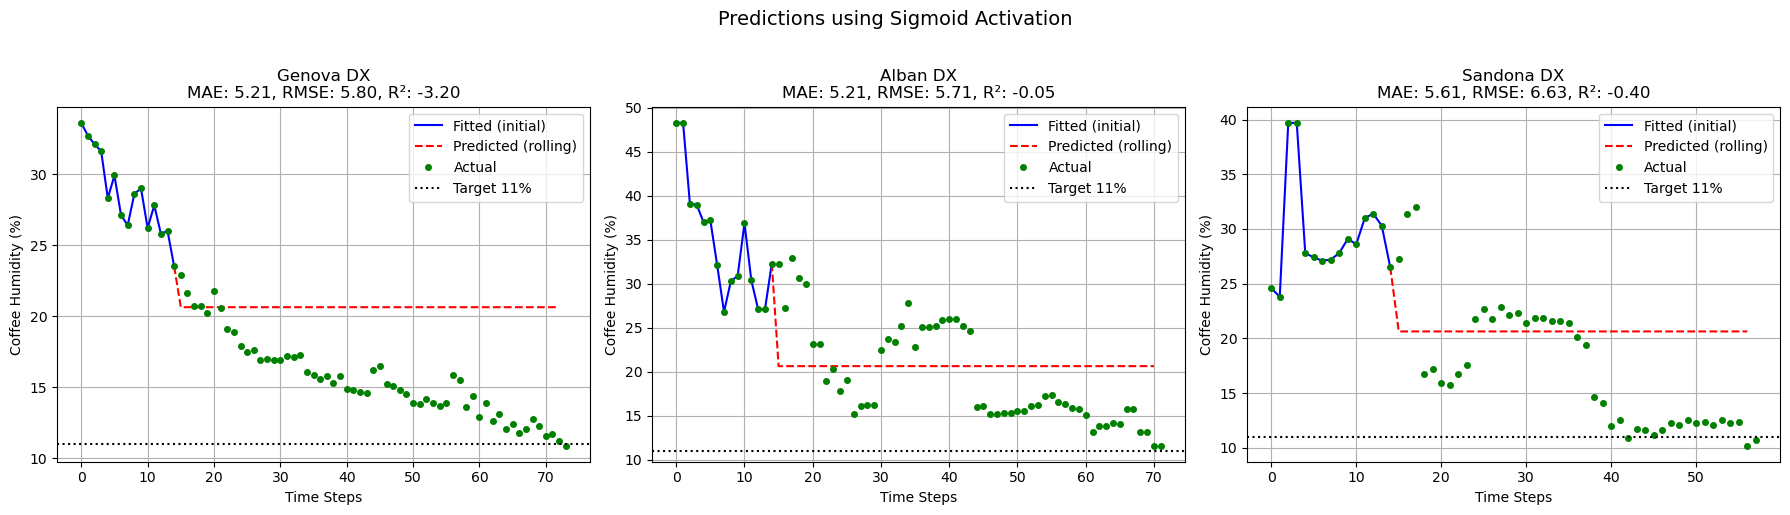


--- Training with SELU activation function ---


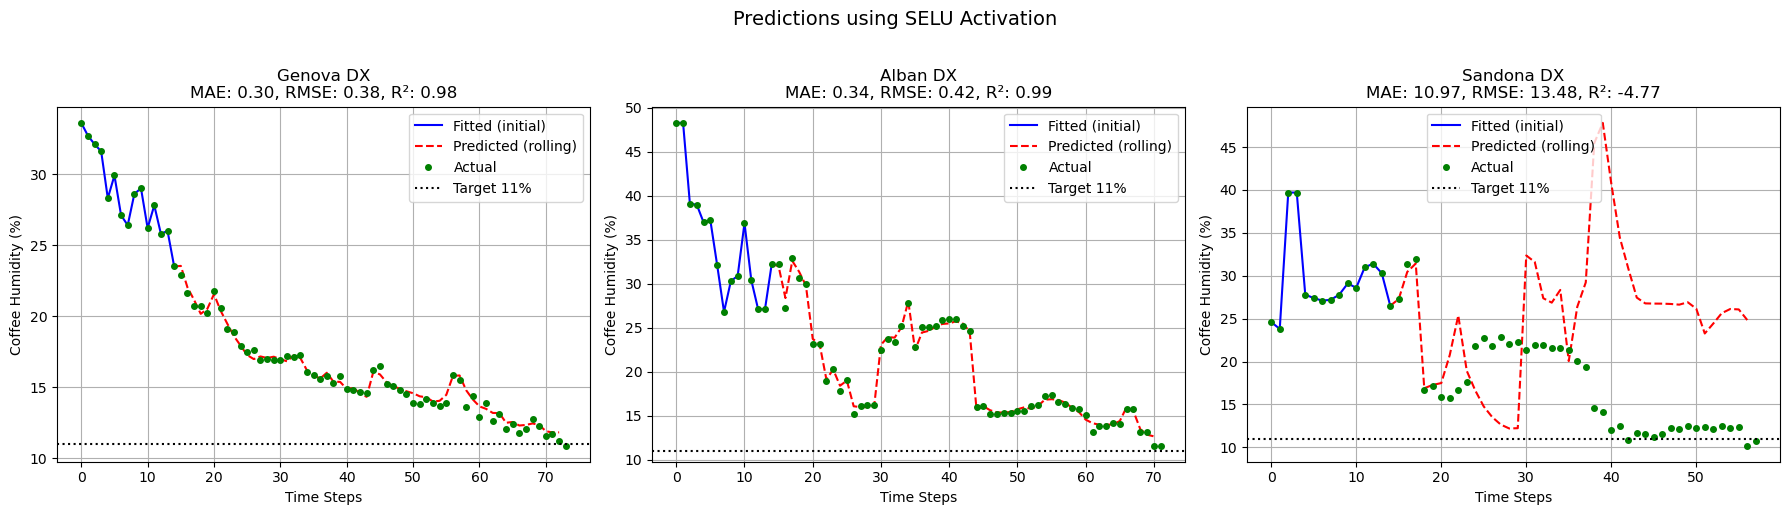


--- Training with ELU activation function ---


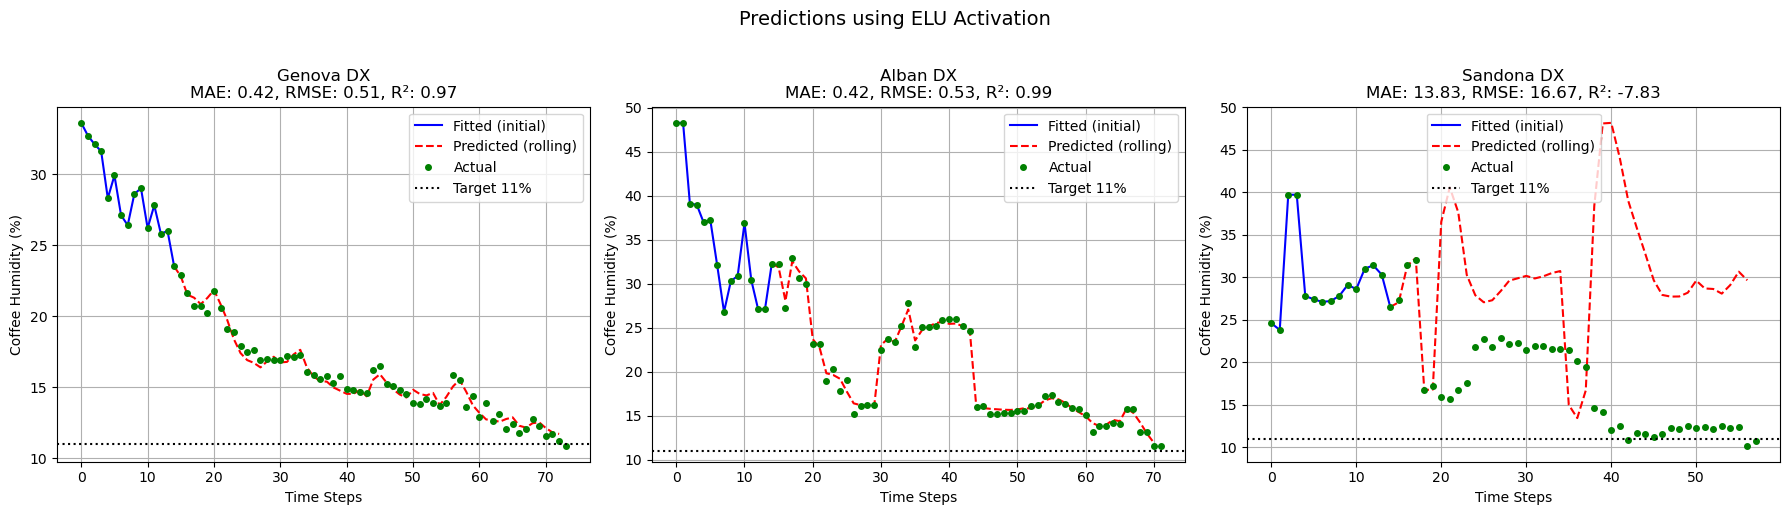


--- Training with LeakyReLU activation function ---


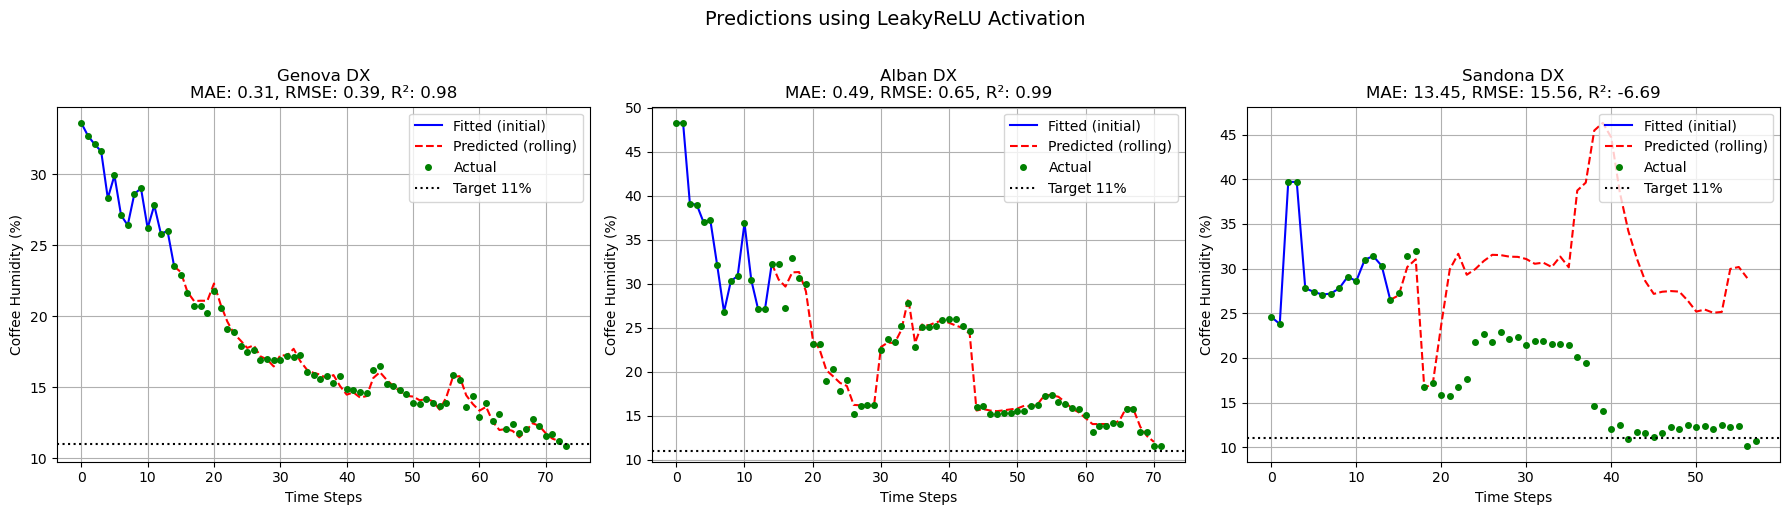

In [33]:

# 10. TRAIN AND EVALUATE EACH ACTIVATION
for activation_name, activation in activations.items():
    print(f"\n--- Training with {activation_name} activation function ---")
    model = build_model(activation)
    history = model.fit(X_train, y_train, epochs=2000, batch_size=64, verbose=0, validation_split=0.2)

    results[activation_name] = {
        'model': model,
        'history': history,
        'val_metrics': {},
        'predictions': {}
    }

    
    n_cols = len(regions)
    plt.figure(figsize=(6 * n_cols, 5))
    plt.suptitle(f'Predictions using {activation_name} Activation', y=1.02, fontsize=14)

    for i, region in enumerate(regions):
        region_data = train_data[train_data['region'] == region].copy()
        # need at least n_steps+1 rows to produce predictions
        if len(region_data) < 16:
            print(f"Skipping region {region} (not enough rows: {len(region_data)})")
            continue

        # ==== actual unscaled target ====
        all_actual = region_data[target].values  # these are scaled values in [0,1]
        # To inverse scale target only, we reconstruct a temporary array of same shape used for scaler:
        tmp = np.zeros((len(all_actual), len(features) + 1), dtype=float)
        tmp[:, -1] = all_actual  # last column is the target
        all_actual_unscaled = scaler.inverse_transform(tmp)[:, -1]

        # ==== prepare rolling prediction ====
        initial_seq = region_data[features].iloc[:15].values  # scaled features
        current_seq = initial_seq.copy()
        predictions = []

        for j in range(15, len(region_data)):
            pred = model.predict(current_seq[np.newaxis, :, :], verbose=0)[0, 0]
            predictions.append(pred)
            # build next input row: features (3 numeric) + region_encoded (already in features)
            next_features = region_data[['Temperature_Overall', 'Humidity_Overall', 'Temperature_Coffee']].iloc[j].values.astype(float)
            next_region_code = float(region_data['region_encoded'].iloc[j])
            new_row = np.hstack([next_features, next_region_code])
            # append predicted target as last element would be used only for inverse-scaling; for current_seq we only keep features
            current_seq = np.vstack([current_seq[1:], new_row])

        if len(predictions) == 0:
            print(f"No predictions for {region} (region length maybe == n_steps).")
            continue

        # inverse transform predictions
        tmp_pred = np.zeros((len(predictions), len(features) + 1), dtype=float)
        tmp_pred[:, -1] = np.array(predictions)
        pred_unscaled = scaler.inverse_transform(tmp_pred)[:, -1]

        # align lengths
        min_len = min(len(all_actual_unscaled[15:]), len(pred_unscaled))
        y_true = all_actual_unscaled[15:15 + min_len]
        y_pred = pred_unscaled[:min_len]

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        results[activation_name]['val_metrics'][region] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        results[activation_name]['predictions'][region] = {'actual': all_actual_unscaled, 'predicted': pred_unscaled}

        # === plotting ===
        plt.subplot(1, n_cols, i + 1)
        time_pts = np.arange(len(all_actual_unscaled))
        plt.plot(time_pts[:15], all_actual_unscaled[:15], 'b-', label='Fitted (initial)')
        plt.plot(time_pts[14:14 + len(pred_unscaled)],
                 [all_actual_unscaled[14]] + list(pred_unscaled[:-1]),
                 'r--', label='Predicted (rolling)')
        plt.plot(time_pts, all_actual_unscaled, 'go', label='Actual', markersize=4)
        plt.axhline(y=11, color='k', linestyle=':', label='Target 11%')
        plt.title(f'{region}\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}')
        plt.xlabel('Time Steps')
        plt.ylabel('Coffee Humidity (%)')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

### 11. Loss history plots
- After training all activations, training and validation loss histories are plotted for visual comparison.

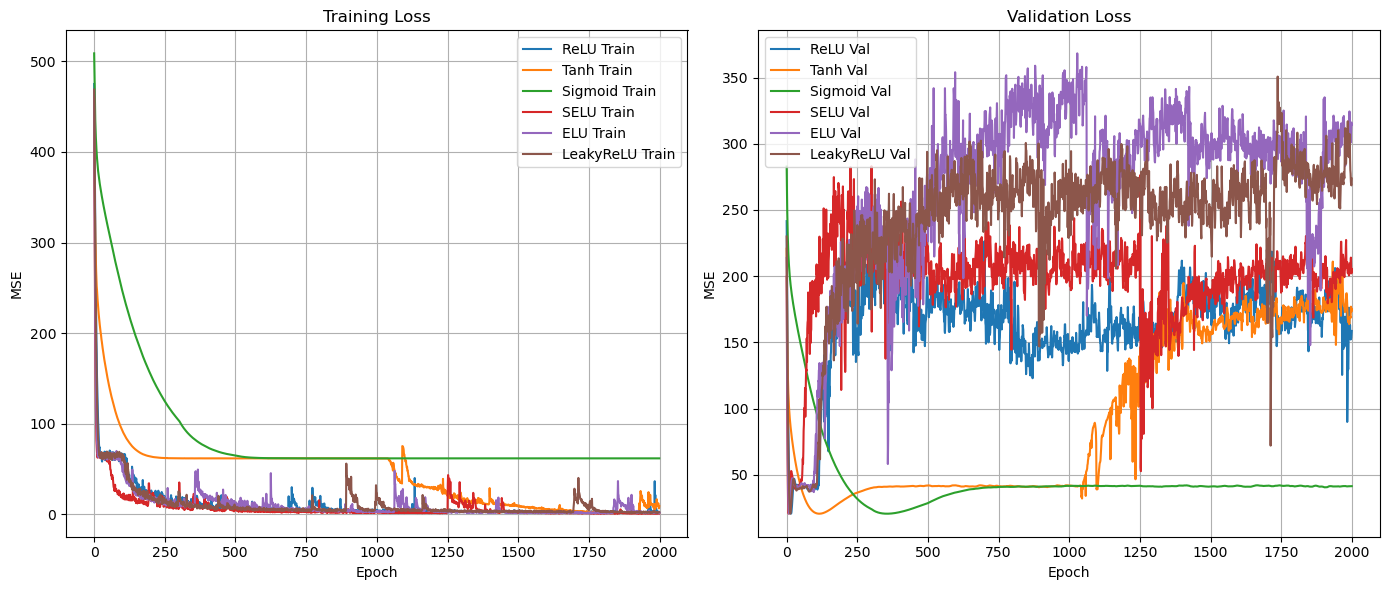

In [34]:

# ======================================
# 11. LOSS HISTORY PLOTS
# ======================================
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
for act, res in results.items():
    plt.plot(res['history'].history['loss'], label=f'{act} Train')
plt.title('Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for act, res in results.items():
    plt.plot(res['history'].history['val_loss'], label=f'{act} Val')
plt.title('Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

### 12. Metrics bar charts
- Bar charts compare MAE, RMSE, and R² across activation functions and regions (if available).


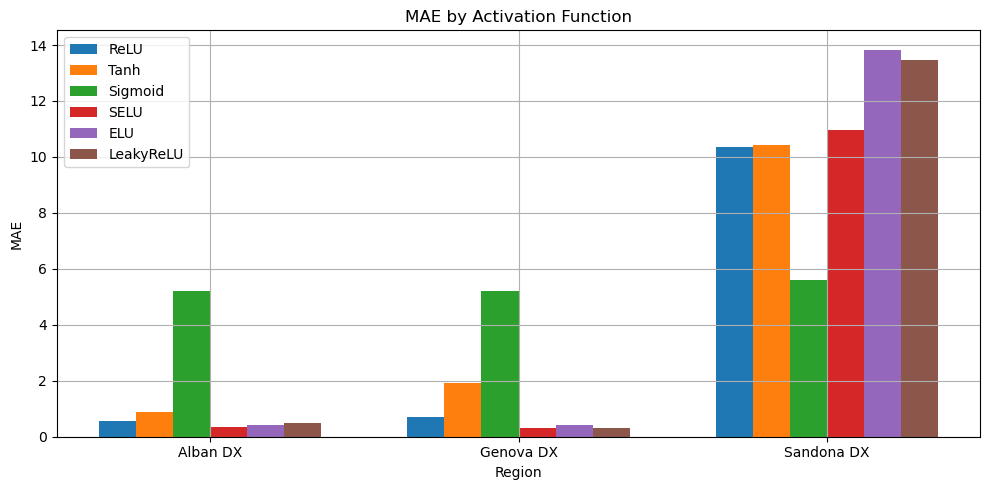

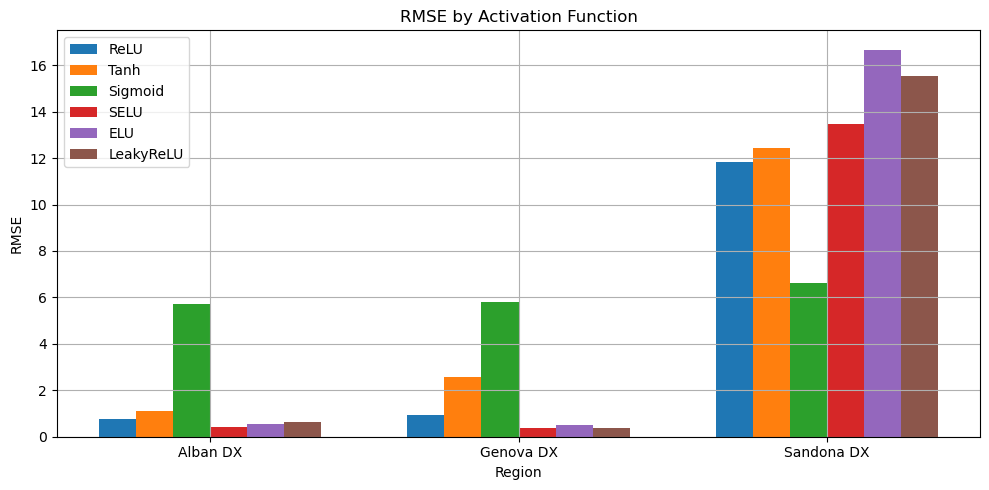

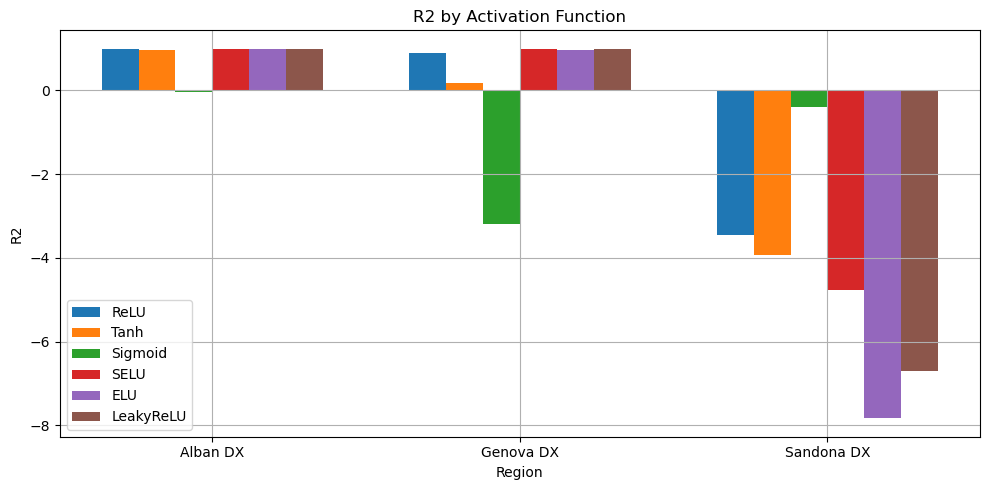

In [35]:
# ======================================
# 12. METRICS BAR CHART
# ======================================
activation_names = list(activations.keys())
# gather regions that have metrics (some activations might not have entries if training failed)
regions_with_data = sorted({r for act in activation_names for r in results[act]['val_metrics'].keys()})
if regions_with_data:
    metrics_list = ['MAE', 'RMSE', 'R2']
    for metric in metrics_list:
        plt.figure(figsize=(10, 5))
        width = 0.12
        x = np.arange(len(regions_with_data))
        for i, act in enumerate(activation_names):
            vals = [results[act]['val_metrics'].get(r, {metric: np.nan})[metric] for r in regions_with_data]
            plt.bar(x + i * width, vals, width, label=act)
        plt.xlabel('Region'); plt.ylabel(metric); plt.title(f'{metric} by Activation Function')
        plt.xticks(x + width * (len(activation_names) - 1) / 2, regions_with_data)
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### 13. Print comparison table
- A simple printed table shows MAE/RMSE/R² per activation and region for quick textual comparison.

In [36]:

# ======================================
# 13. PRINT COMPARISON TABLE
# ======================================
print("\nFinal Comparison:")
header = f"{'Activation':<12} | {'Region':<12} | {'MAE':<10} | {'RMSE':<10} | {'R2':<10}"
print(header)
print("-" * len(header))
for act in activation_names:
    for region in regions_with_data:
        metrics = results[act]['val_metrics'].get(region, {'MAE': np.nan, 'RMSE': np.nan, 'R2': np.nan})
        print(f"{act:<12} | {region:<12} | {metrics['MAE']:<10.3f} | {metrics['RMSE']:<10.3f} | {metrics['R2']:<10.3f}")


Final Comparison:
Activation   | Region       | MAE        | RMSE       | R2        
------------------------------------------------------------------
ReLU         | Alban DX     | 0.551      | 0.767      | 0.981     
ReLU         | Genova DX    | 0.691      | 0.924      | 0.893     
ReLU         | Sandona DX   | 10.343     | 11.842     | -3.456    
Tanh         | Alban DX     | 0.870      | 1.103      | 0.961     
Tanh         | Genova DX    | 1.923      | 2.581      | 0.168     
Tanh         | Sandona DX   | 10.428     | 12.451     | -3.926    
Sigmoid      | Alban DX     | 5.211      | 5.707      | -0.046    
Sigmoid      | Genova DX    | 5.215      | 5.799      | -3.199    
Sigmoid      | Sandona DX   | 5.606      | 6.629      | -0.396    
SELU         | Alban DX     | 0.337      | 0.421      | 0.994     
SELU         | Genova DX    | 0.304      | 0.381      | 0.982     
SELU         | Sandona DX   | 10.970     | 13.475     | -4.770    
ELU          | Alban DX     | 0.416      | 

### 14. Combined prediction plots (activation comparison)
- For each region, plots predicted sequences from all activations together with the actual values to visually compare which activation tracks the real curve best.

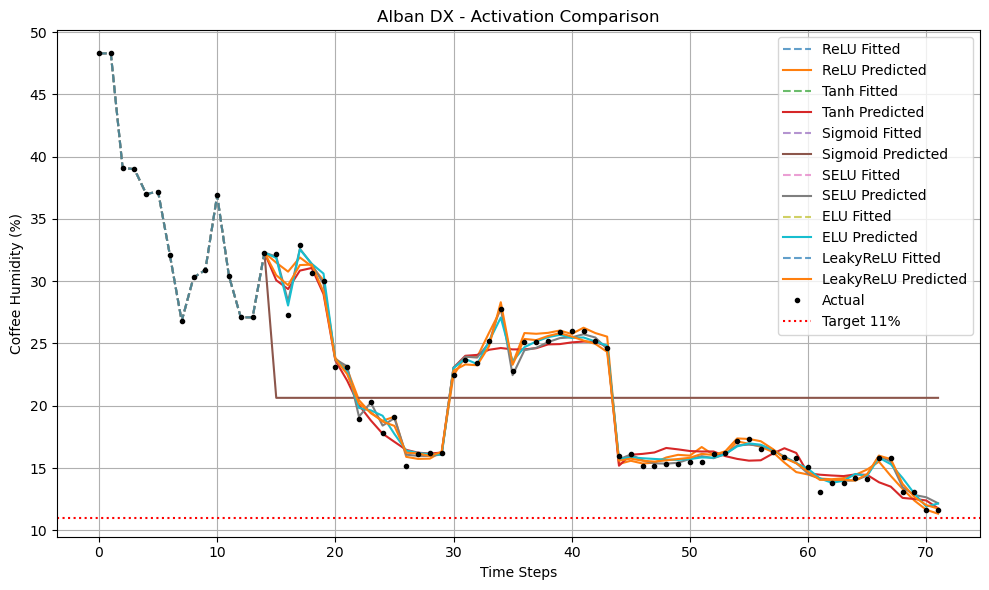

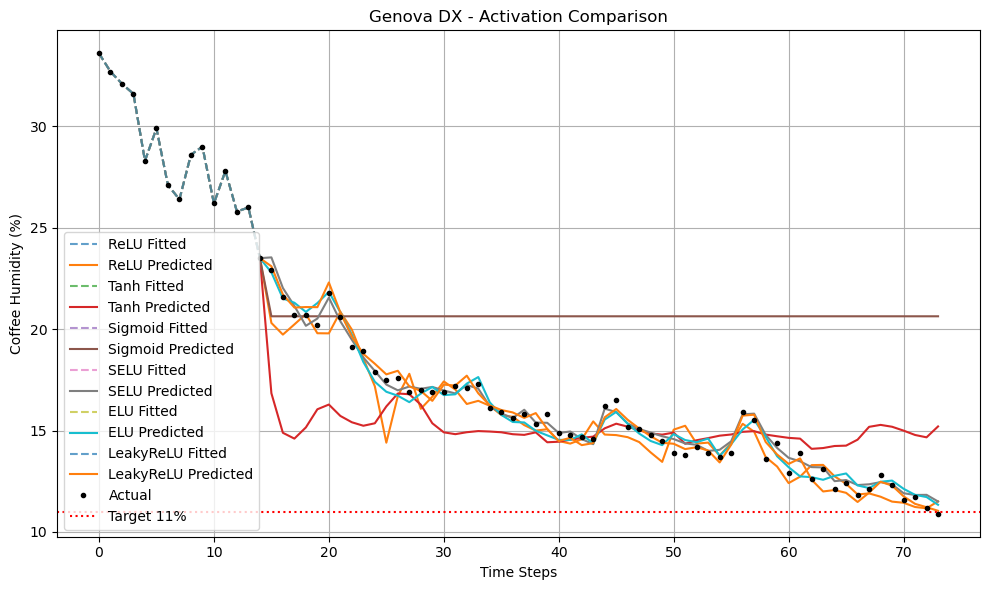

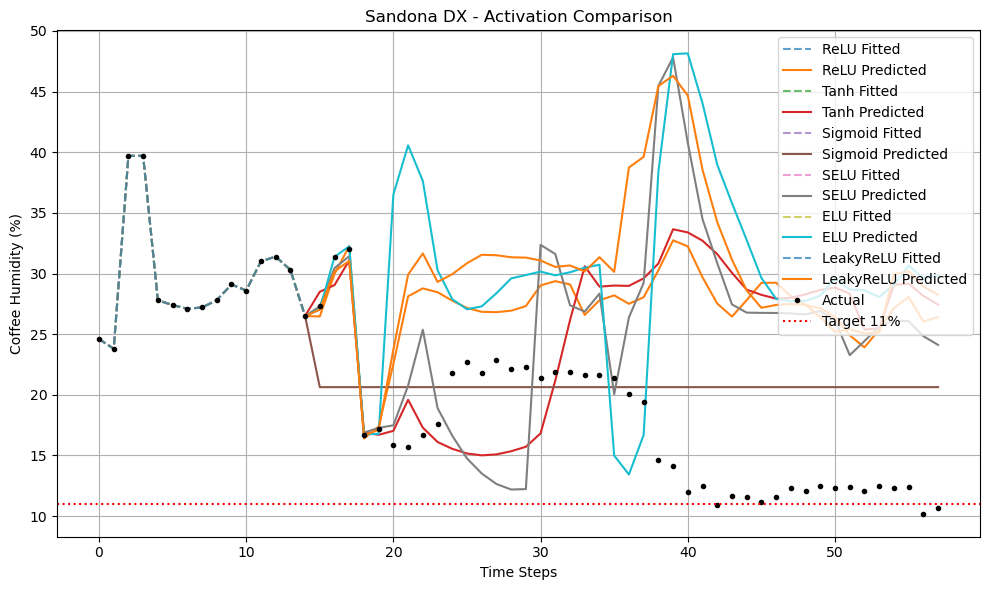

In [37]:
# ======================================
# 14. COMBINED PREDICTION PLOTS (activations vs actual) 
# ======================================
for region in regions_with_data:
    plt.figure(figsize=(10, 6))
    for act in activation_names:
        if region in results[act]['predictions']:
            data_pred = results[act]['predictions'][region]
            t = np.arange(len(data_pred['actual']))
            pred_len = len(data_pred['predicted'])
            
            # Plot fitted part (initial sequence)
            plt.plot(t[:15], data_pred['actual'][:15], '--', alpha=0.7, label=f'{act} Fitted')
            
            # Plot predicted part - FIX: adjust time array to match prediction length
            pred_with_connection = np.concatenate([[data_pred['actual'][14]], data_pred['predicted']])
            t_pred = np.arange(14, 14 + len(pred_with_connection))
            plt.plot(t_pred, pred_with_connection, '-', label=f'{act} Predicted')
    
    # plot actual
    plt.plot(t, data_pred['actual'], 'ko', markersize=3, label='Actual')
    plt.axhline(y=11, color='r', linestyle=':', label='Target 11%')
    plt.title(f'{region} - Activation Comparison')
    plt.xlabel('Time Steps')
    plt.ylabel('Coffee Humidity (%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()